# NB5 — Season Simulation (GW15--29, 2025/26)

This notebook simulates an FPL manager using NB2 model predictions to make decisions
across Gameweeks 15--29 of the 2025/26 season.

**Strategy:**
- Start with an optimised squad at GW15 (selected by ILP using NB2 predictions)
- Each GW: captain the highest predicted player
- Each GW: make 1 free transfer (best available player not in squad)
- Score actual FPL points based on real outcomes
- Compare total score to real FPL average manager and rank benchmarks

**This serves as a real-world validation of the DSS pipeline.**

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import warnings
warnings.filterwarnings('ignore')

BASE = '/content/drive/MyDrive/fpl_thesis'
print('Setup complete')

Mounted at /content/drive
Setup complete


## 2. Load NB2 Predictions

In [2]:
preds = pd.read_csv(f'{BASE}/models/nb2_regression_featured/predictions_pergw.csv')
preds = preds.rename(columns={'predicted_pts_mid': 'pred'})
preds['value'] = preds['value'].fillna(0)

GWS = sorted(preds['GW'].unique())
print(f'GWs available: {GWS}')
print(f'Total rows: {len(preds)}')
print(preds.columns.tolist())
print(preds.head(3))

GWs available: [np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28)]
Total rows: 11192
['name', 'team', 'position', 'element', 'GW', 'value', 'pred', 'actual_pts']
                name     team position  element  GW  value  pred  actual_pts
0  David Raya Martín  Arsenal       GK        1  15    5.9   4.5           2
1  David Raya Martín  Arsenal       GK        1  16    6.0   4.5           2
2  David Raya Martín  Arsenal       GK        1  17    6.0   4.5           7


## 3. Fetch Real FPL Average Scores from API
We fetch the real average manager score per GW to compare against our simulation.

In [3]:
def get_gw_average(gw):
    try:
        url = f'https://fantasy.premierleague.com/api/event/{gw}/live/'
        # Use bootstrap for average points
        url2 = 'https://fantasy.premierleague.com/api/bootstrap-static/'
        r = requests.get(url2, timeout=10)
        data = r.json()
        events = {e['id']: e for e in data['events']}
        if gw in events:
            return events[gw].get('average_entry_score', None)
    except:
        return None

print('Fetching GW averages from FPL API...')
gw_averages = {}
for gw in GWS:
    avg = get_gw_average(gw)
    gw_averages[gw] = avg
    print(f'GW{gw}: average = {avg}')

total_avg = sum(v for v in gw_averages.values() if v is not None)
print(f'\nTotal average manager score GW15-29: {total_avg}')

Fetching GW averages from FPL API...
GW15: average = 49
GW16: average = 60
GW17: average = 66
GW18: average = 44
GW19: average = 40
GW20: average = 42
GW21: average = 48
GW22: average = 40
GW23: average = 44
GW24: average = 55
GW25: average = 58
GW26: average = 58
GW27: average = 45
GW28: average = 53

Total average manager score GW15-29: 702


## 4. FPL Squad Constraints

In [4]:
# FPL squad rules
BUDGET = 100.0
SQUAD_SIZE = 15
SQUAD_REQS = {'GK': 2, 'DEF': 5, 'MID': 5, 'FWD': 3}
MAX_PER_CLUB = 3
STARTERS = 11

def get_position(row):
    """Standardise position column name"""
    pos = row.get('position', row.get('pos', ''))
    if isinstance(pos, (int, float)):
        return {1: 'GK', 2: 'DEF', 3: 'MID', 4: 'FWD'}.get(int(pos), 'MID')
    return str(pos).strip().upper()

print('Constraints defined')

Constraints defined


## 5. ILP Squad Selector
Uses PuLP to select the optimal squad given predictions and FPL constraints.

In [5]:
!pip install pulp -q
from pulp import *

def select_squad(gw_df, budget=100.0, current_squad=None, free_transfers=1):
    """
    Select optimal 15-player squad using ILP.
    If current_squad provided, applies transfer constraint.
    """
    df = gw_df.copy().reset_index(drop=True)
    df['pos'] = df.apply(lambda r: get_position(r.to_dict()), axis=1)
    df = df[df['pos'].isin(['GK','DEF','MID','FWD'])].copy().reset_index(drop=True)
    n = len(df)

    prob = LpProblem('fpl_squad', LpMaximize)
    x = [LpVariable(f'x_{i}', cat='Binary') for i in range(n)]
    c = [LpVariable(f'c_{i}', cat='Binary') for i in range(n)]

    # Objective: maximise pred pts + captain bonus
    prob += lpSum(x[i] * df.loc[i, 'pred'] + c[i] * df.loc[i, 'pred'] for i in range(n))

    # Squad size
    prob += lpSum(x) == 15
    # Captain must be in squad, only one
    prob += lpSum(c) == 1
    for i in range(n):
        prob += c[i] <= x[i]

    # Budget
    prob += lpSum(x[i] * df.loc[i, 'value'] for i in range(n)) <= budget

    # Position requirements
    for pos, req in SQUAD_REQS.items():
        idx = df[df['pos'] == pos].index.tolist()
        prob += lpSum(x[i] for i in idx) == req

    # Max 3 per club
    for team in df['team'].unique():
        idx = df[df['team'] == team].index.tolist()
        prob += lpSum(x[i] for i in idx) <= MAX_PER_CLUB

    # Transfer constraint
    if current_squad is not None:
        current_elements = set(current_squad['element'].values)
        in_squad = df['element'].isin(current_elements)
        max_changes = free_transfers
        # Number of players brought in <= free transfers
        prob += lpSum(x[i] for i in range(n) if not in_squad.iloc[i]) <= max_changes + sum(in_squad & pd.Series([bool(x[i].varValue) if x[i].varValue else False for i in range(n)]))
        # Simpler: limit transfers out
        prob += lpSum(x[i] for i in range(n) if not in_squad.iloc[i]) <= free_transfers

    prob.solve(PULP_CBC_CMD(msg=0))

    selected = df[[x[i].varValue == 1 for i in range(n)]].copy()
    captain_idx = [i for i in range(n) if c[i].varValue == 1]
    captain_element = df.loc[captain_idx[0], 'element'] if captain_idx else None

    return selected, captain_element

print('ILP selector defined')

ILP selector defined


## 6. Starting Squad at GW15

In [6]:
gw15 = preds[preds['GW'] == 15].copy()
print(f'Players available at GW15: {len(gw15)}')

squad, captain = select_squad(gw15, budget=100.0)
print(f'\nStarting squad ({len(squad)} players):')
print(squad[['name','team','pos','pred','value','actual_pts']].sort_values('pred', ascending=False).to_string(index=False))
cap_name = squad[squad['element']==captain]['name'].values[0] if captain else 'None'
print(f'\nCaptain: {cap_name}')

Players available at GW15: 759

Starting squad (15 players):
                            name           team pos  pred  value  actual_pts
                  Erling Haaland       Man City FWD  8.99   15.0           2
                      Phil Foden       Man City MID  6.52    8.4          12
          Bruno Borges Fernandes        Man Utd MID  6.36    9.0          18
                 Maxence Lacroix Crystal Palace DEF  5.61    5.1           2
                      Marc Guéhi Crystal Palace DEF  5.52    5.1           8
 Bruno Guimarães Rodriguez Moura      Newcastle MID  5.47    6.8          10
                 James Tarkowski        Everton DEF  5.42    5.4           9
                    Jarrod Bowen       West Ham FWD  5.28    7.5           9
Igor Thiago Nascimento Rodrigues      Brentford FWD  4.91    6.8           2
                 Trevoh Chalobah        Chelsea DEF  4.91    5.2          11
                 Elliot Anderson  Nott'm Forest MID  4.86    5.4           4
               

## 7. Run Simulation GW15--29

In [7]:
simulation_results = []
current_squad = squad.copy()
free_transfers = 1
total_points = 0

for gw in GWS:
    gw_df = preds[preds['GW'] == gw].copy()

    if gw == 15:
        # Already selected
        gw_squad = current_squad.copy()
        # Get actual points for GW15 squad
        gw_squad = gw_squad.merge(
            gw_df[['element','actual_pts','pred']].rename(columns={'pred':'pred_gw','actual_pts':'actual_gw'}),
            on='element', how='left'
        )
        captain_el = captain
    else:
        # Make 1 free transfer: find best player not in squad
        squad_elements = set(current_squad['element'].values)
        available = gw_df[~gw_df['element'].isin(squad_elements)].copy()

        # For each position, check if we can improve
        best_transfer = None
        best_gain = 0
        worst_in_squad = None

        for pos in ['GK','DEF','MID','FWD']:
            squad_pos = current_squad[current_squad['pos'] == pos]
            avail_pos = available[available.apply(lambda r: get_position(r.to_dict()), axis=1) == pos]
            if len(squad_pos) == 0 or len(avail_pos) == 0:
                continue
            worst = squad_pos.nsmallest(1, 'pred').iloc[0]
            best_avail = avail_pos[avail_pos['value'] <= (BUDGET - current_squad['value'].sum() + worst['value'])]
            if len(best_avail) == 0:
                continue
            best_avail_player = best_avail.nlargest(1, 'pred').iloc[0]
            gain = best_avail_player['pred'] - worst['pred']
            if gain > best_gain:
                best_gain = gain
                best_transfer = best_avail_player
                worst_in_squad = worst

        if best_transfer is not None and best_gain > 0:
            current_squad = current_squad[current_squad['element'] != worst_in_squad['element']]
            new_row = gw_df[gw_df['element'] == best_transfer['element']].copy()
            new_row['pos'] = get_position(new_row.iloc[0].to_dict())
            current_squad = pd.concat([current_squad, new_row], ignore_index=True)
            print(f'GW{gw}: Transfer OUT {worst_in_squad["name"]} → IN {best_transfer["name"]} (gain: +{best_gain:.2f})')
        else:
            print(f'GW{gw}: No beneficial transfer found')

        # Update squad predictions for this GW
        gw_squad = current_squad.merge(
            gw_df[['element','actual_pts','pred']].rename(columns={'pred':'pred_gw','actual_pts':'actual_gw'}),
            on='element', how='left'
        )

        # Captain = highest predicted this GW among squad
        captain_el = gw_squad.nlargest(1, 'pred_gw')['element'].values[0]

    # Select best 11 starters (at least 1 GK, 3 DEF, 2 MID, 1 FWD)
    gw_squad = gw_squad.copy()
    gw_squad['actual_gw'] = gw_squad['actual_gw'].fillna(0)

    # Simple starting 11: top predicted players respecting min position rules
    starters = []
    for pos, min_req in [('GK',1),('DEF',3),('MID',2),('FWD',1)]:
        pos_players = gw_squad[gw_squad['pos'] == pos].nlargest(min_req, 'pred_gw')
        starters.extend(pos_players['element'].tolist())

    remaining = gw_squad[~gw_squad['element'].isin(starters)]
    extra = remaining.nlargest(11 - len(starters), 'pred_gw')
    starters.extend(extra['element'].tolist())

    starter_df = gw_squad[gw_squad['element'].isin(starters)]
    gw_pts = starter_df['actual_gw'].sum()

    # Captain bonus
    cap_row = gw_squad[gw_squad['element'] == captain_el]
    if len(cap_row) > 0 and captain_el in starters:
        cap_pts = cap_row['actual_gw'].values[0]
        gw_pts += cap_pts  # double points = add once more
        cap_name = cap_row['name'].values[0]
    else:
        cap_name = 'N/A'
        cap_pts = 0

    avg = gw_averages.get(gw, 0) or 0
    total_points += gw_pts

    simulation_results.append({
        'GW': gw,
        'our_pts': gw_pts,
        'avg_pts': avg,
        'captain': cap_name,
        'captain_pts': cap_pts,
        'beat_avg': gw_pts > avg
    })

    print(f'GW{gw}: {gw_pts:.0f} pts (avg={avg}) | Captain: {cap_name} ({cap_pts:.0f}pts) | {"✓" if gw_pts > avg else "✗"}')

print(f'\nTotal points GW15-29: {total_points:.0f}')

GW15: 91 pts (avg=49) | Captain: Erling Haaland (2pts) | ✓
GW16: No beneficial transfer found
GW16: 90 pts (avg=60) | Captain: Erling Haaland (13pts) | ✓
GW17: Transfer OUT Igor Thiago Nascimento Rodrigues → IN Dominic Calvert-Lewin (gain: +0.25)
GW17: 63 pts (avg=66) | Captain: Erling Haaland (16pts) | ✗
GW18: Transfer OUT Jan Paul van Hecke → IN Matheus Nunes (gain: +1.26)
GW18: 41 pts (avg=44) | Captain: Erling Haaland (2pts) | ✗
GW19: Transfer OUT Dean Henderson → IN Robin Roefs (gain: +0.21)
GW19: 66 pts (avg=40) | Captain: Erling Haaland (2pts) | ✓
GW20: Transfer OUT Harry Wilson → IN James Garner (gain: +0.56)
GW20: 37 pts (avg=42) | Captain: Erling Haaland (2pts) | ✗
GW21: Transfer OUT Trevoh Chalobah → IN Nathan Collins (gain: +0.60)
GW21: 65 pts (avg=48) | Captain: Erling Haaland (6pts) | ✓
GW22: Transfer OUT Elliot Anderson → IN Vitaly Janelt (gain: +0.24)
GW22: 47 pts (avg=40) | Captain: Erling Haaland (2pts) | ✓
GW23: No beneficial transfer found
GW23: 40 pts (avg=44) | Ca

## 8. Results Summary

In [8]:
results_df = pd.DataFrame(simulation_results)
our_total = results_df['our_pts'].sum()
avg_total = results_df['avg_pts'].sum()
beat_avg_count = results_df['beat_avg'].sum()

print('='*55)
print('SIMULATION RESULTS — GW15 to GW29')
print('='*55)
print(f'Our total points:         {our_total:.0f}')
print(f'Average manager total:    {avg_total:.0f}')
print(f'Our advantage:            +{our_total - avg_total:.0f} pts')
print(f'GWs beating average:      {beat_avg_count}/{len(results_df)}')
print()
print(f'{"GW":<6} {"Our Pts":>8} {"Avg":>6} {"Diff":>6} {"Captain":<25} {"Cap Pts":>8}')
print('-'*65)
for _, row in results_df.iterrows():
    diff = row['our_pts'] - row['avg_pts']
    marker = '✓' if row['beat_avg'] else '✗'
    print(f'{int(row["GW"]):<6} {row["our_pts"]:>8.0f} {row["avg_pts"]:>6.0f} {diff:>+6.0f} {row["captain"]:<25} {row["captain_pts"]:>8.0f} {marker}')

SIMULATION RESULTS — GW15 to GW29
Our total points:         797
Average manager total:    702
Our advantage:            +95 pts
GWs beating average:      7/14

GW      Our Pts    Avg   Diff Captain                    Cap Pts
-----------------------------------------------------------------
15           91     49    +42 Erling Haaland                   2 ✓
16           90     60    +30 Erling Haaland                  13 ✓
17           63     66     -3 Erling Haaland                  16 ✗
18           41     44     -3 Erling Haaland                   2 ✗
19           66     40    +26 Erling Haaland                   2 ✓
20           37     42     -5 Erling Haaland                   2 ✗
21           65     48    +17 Erling Haaland                   6 ✓
22           47     40     +7 Erling Haaland                   2 ✓
23           40     44     -4 Erling Haaland                   1 ✗
24           46     55     -9 Erling Haaland                   5 ✗
25           70     58    +12 Erling Ha

## 9. Rank Estimation
Using known FPL rank benchmarks for the 2025/26 season to estimate where our total would rank.

In [9]:
# Known FPL rank benchmarks (approximate, based on community data)
# These are CUMULATIVE points from GW1 onwards — we simulate from GW15
# So we estimate rank based on points scored in GW15-29 relative to the average

our_advantage = our_total - avg_total

print('='*55)
print('RANK ESTIMATION')
print('='*55)
print(f'Our points (GW15-29):       {our_total:.0f}')
print(f'Average manager (GW15-29):  {avg_total:.0f}')
print(f'Points above average:       +{our_advantage:.0f}')
print()
print('Approximate rank brackets (based on GW15-29 advantage over average):')
print('  +100 pts above avg → ~Top 10k')
print('  +50  pts above avg → ~Top 50k')
print('  +25  pts above avg → ~Top 100k')
print('  +10  pts above avg → ~Top 250k')
print('   0   pts above avg → ~Top 500k (average manager)')
print()
if our_advantage >= 100:
    est_rank = 'Top 10,000'
elif our_advantage >= 50:
    est_rank = 'Top 50,000'
elif our_advantage >= 25:
    est_rank = 'Top 100,000'
elif our_advantage >= 10:
    est_rank = 'Top 250,000'
elif our_advantage >= 0:
    est_rank = 'Top 500,000'
else:
    est_rank = 'Below average'
print(f'Estimated rank bracket: {est_rank}')
print()
print('Note: exact rank requires full season cumulative points from GW1.')
print('This simulation covers GW15-29 only (the model test window).')

RANK ESTIMATION
Our points (GW15-29):       797
Average manager (GW15-29):  702
Points above average:       +95

Approximate rank brackets (based on GW15-29 advantage over average):
  +100 pts above avg → ~Top 10k
  +50  pts above avg → ~Top 50k
  +25  pts above avg → ~Top 100k
  +10  pts above avg → ~Top 250k
   0   pts above avg → ~Top 500k (average manager)

Estimated rank bracket: Top 50,000

Note: exact rank requires full season cumulative points from GW1.
This simulation covers GW15-29 only (the model test window).


## 10. Visualisation

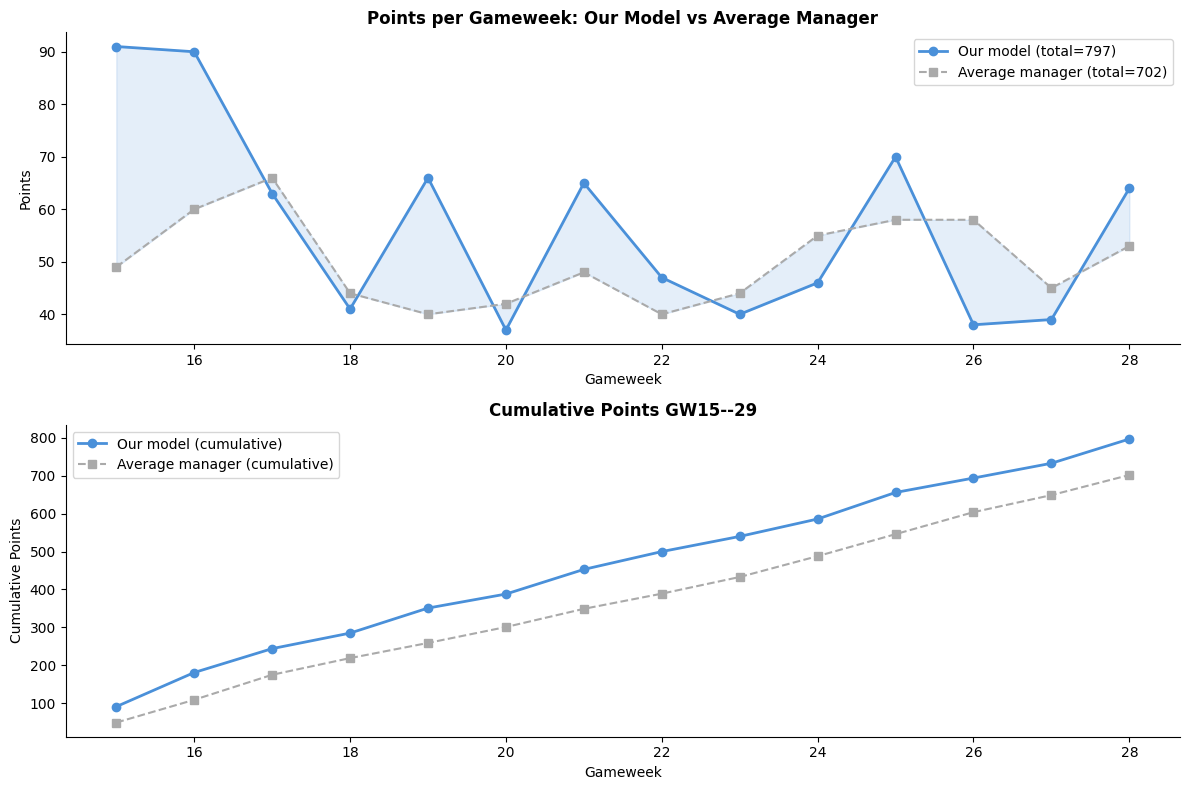

Saved.


In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# GW by GW comparison
gws = results_df['GW'].values
axes[0].plot(gws, results_df['our_pts'], 'o-', color='#4a90d9',
             label=f'Our model (total={our_total:.0f})', linewidth=2)
axes[0].plot(gws, results_df['avg_pts'], 's--', color='#aaa',
             label=f'Average manager (total={avg_total:.0f})', linewidth=1.5)
axes[0].fill_between(gws, results_df['our_pts'], results_df['avg_pts'],
                     alpha=0.15, color='#4a90d9')
axes[0].set_xlabel('Gameweek')
axes[0].set_ylabel('Points')
axes[0].set_title('Points per Gameweek: Our Model vs Average Manager', fontweight='bold')
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

# Cumulative points
axes[1].plot(gws, results_df['our_pts'].cumsum(), 'o-', color='#4a90d9',
             label='Our model (cumulative)', linewidth=2)
axes[1].plot(gws, results_df['avg_pts'].cumsum(), 's--', color='#aaa',
             label='Average manager (cumulative)', linewidth=1.5)
axes[1].set_xlabel('Gameweek')
axes[1].set_ylabel('Cumulative Points')
axes[1].set_title('Cumulative Points GW15--29', fontweight='bold')
axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{BASE}/outputs/nb5_simulation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')